# Deep Neural Network from Scratch

An L-layer neural network built using only NumPy — no frameworks.

**Architecture:** `X → [Z=WA+b → A=tanh(Z)] × (L-1) → Z=WA+b → A=sigmoid(Z) → Loss`

Hidden layers use tanh. Output layer uses sigmoid. Number of layers and nodes are configurable.

Applied to the Cat vs Non-Cat dataset.

In [1]:
import numpy as np
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

## Load Data

Cat vs Non-Cat dataset — 209 training examples, 50 test examples.  
Each image is 64×64 RGB, flattened to a vector of 12,288 features.

In [2]:
def load_data():
    """Loads the cat vs non-cat dataset. Searches for datasets/ folder automatically."""
    
    search_dir = Path().resolve()
    for _ in range(3):
        datasets_path = search_dir / 'datasets'
        if datasets_path.exists():
            break
        search_dir = search_dir.parent
    
    train = h5py.File(datasets_path / 'train_catvnoncat.h5', 'r')
    test  = h5py.File(datasets_path / 'test_catvnoncat.h5', 'r')
    
    X_train = np.array(train['train_set_x']) / 255.0
    y_train = np.array(train['train_set_y']).reshape(1, -1)
    
    X_test  = np.array(test['test_set_x']) / 255.0
    y_test  = np.array(test['test_set_y']).reshape(1, -1)
    
    # Flatten images: (m, 64, 64, 3) → (12288, m)
    X_train = X_train.reshape(X_train.shape[0], -1).T
    X_test  = X_test.reshape(X_test.shape[0], -1).T
    
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_test shape:  {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data()

X_train shape: (12288, 209)
y_train shape: (1, 209)
X_test shape:  (12288, 50)
y_test shape:  (1, 50)


## Core Functions

### Forward Propagation (for each layer l)
```
Z[l] = W[l] · A[l-1] + b[l]
A[l] = tanh(Z[l])       for l = 1 to L-1  (hidden layers)
A[L] = sigmoid(Z[L])    for l = L          (output layer)
```

### Backward Propagation (for each layer l, going L to 1)
```
# Output layer:
dZ[L] = A[L] - Y

# Hidden layers:
dZ[l] = dL/dZ[l] = (dL/dA[l]) · (dA[l]/dZ[l])
      = W[l+1].T · dZ[l+1]  *  (1 - tanh(Z[l])²)

# All layers:
dW[l] = dZ[l] · A[l-1].T / m
db[l] = sum(dZ[l]) / m
```

In [3]:
def sigmoid(z):
    """Applies sigmoid activation elementwise. Output is between 0 and 1."""
    return 1 / (1 + np.exp(-z))


def initialize_params(dim1, dim2):
    """Random initialization scaled by 0.01 to avoid saturation at start of training."""
    W = np.random.randn(dim1, dim2) * 0.01
    b = np.zeros((dim1, 1))
    return W, b


def propagate(X, y, layers, nodes, parameters):
    """Full forward pass + full backward pass for L layers."""
    
    m = X.shape[1]
    W, b = parameters['W'], parameters['b']

    Z, A, dz, dw, db = {}, {}, {}, {}, {}
    A['A0'] = X

    # Forward pass
    for l in range(1, layers + 1):
        Z[f'Z{l}'] = np.dot(W[f'W{l}'], A[f'A{l-1}']) + b[f'b{l}']
        if l == layers:
            A[f'A{l}'] = sigmoid(Z[f'Z{l}'])    # output layer
        else:
            A[f'A{l}'] = np.tanh(Z[f'Z{l}'])    # hidden layers

    # Loss
    AL = A[f'A{layers}']
    loss = -np.sum(y * np.log(AL) + (1 - y) * np.log(1 - AL)) / m

    # Backward pass
    for l in range(layers, 0, -1):
        if l == layers:
            # Output layer: dZ = dL/dZ = A - Y  (sigmoid + cross entropy shortcut)
            dz[f'dz{l}'] = A[f'A{l}'] - y
        else:
            # Hidden layer: dZ[l] = dL/dZ[l] = (dL/dA[l]) · (dA[l]/dZ[l])
            # dL/dA[l]   = W[l+1].T · dZ[l+1]   (error flowing back from next layer)
            # dA[l]/dZ[l] = 1 - tanh(Z[l])^2     (tanh derivative)
            dz[f'dz{l}'] = np.dot(W[f'W{l+1}'].T, dz[f'dz{l+1}']) * (1 - np.tanh(Z[f'Z{l}']) ** 2)

        dw[f'dw{l}'] = np.dot(dz[f'dz{l}'], A[f'A{l-1}'].T) / m
        db[f'db{l}'] = np.sum(dz[f'dz{l}'], axis=1, keepdims=True) / m

    return {"dw": dw, "db": db}, loss


def optimize(X, y, layers, nodes, parameters, learning_rate, epochs, print_cost):
    """Gradient descent loop. Updates all weights and biases over epochs."""
    
    costs = []

    for i in range(epochs + 1):

        gradients, loss = propagate(X, y, layers, nodes, parameters)
        costs.append(loss)

        dw, db = gradients['dw'], gradients['db']

        for l in range(1, layers + 1):
            parameters['W'][f'W{l}'] -= learning_rate * dw[f'dw{l}']
            parameters['b'][f'b{l}'] -= learning_rate * db[f'db{l}']

        if print_cost and i % 100 == 0:
            print(f"Iteration {i:4d}: Loss = {loss:.6f}")

    return parameters, costs


def predict(X, parameters, layers):
    """Runs forward pass and thresholds at 0.5 to get binary predictions."""
    
    W, b = parameters['W'], parameters['b']
    Z, A = {}, {}
    A['A0'] = X

    for l in range(1, layers + 1):
        Z[f'Z{l}'] = np.dot(W[f'W{l}'], A[f'A{l-1}']) + b[f'b{l}']
        if l == layers:
            A[f'A{l}'] = sigmoid(Z[f'Z{l}'])
        else:
            A[f'A{l}'] = np.tanh(Z[f'Z{l}'])

    return (A[f'A{layers}'] > 0.5).astype(int)


def model(X_train, y_train, layers=2, nodes={1: 4, 2: 1}, learning_rate=0.01, epochs=1000, print_cost=False):
    """Initializes parameters for L layers and runs gradient descent."""
    
    features = X_train.shape[0]
    W, b = {}, {}

    for l in range(1, layers + 1):
        if l == 1:
            W[f'W{l}'], b[f'b{l}'] = initialize_params(nodes[l], features)
        else:
            W[f'W{l}'], b[f'b{l}'] = initialize_params(nodes[l], nodes[l-1])

    parameters = {"W": W, "b": b}
    return optimize(X_train, y_train, layers, nodes, parameters, learning_rate, epochs, print_cost)

## Train the Model

Define the architecture using `layers` and `nodes`:
- `layers` — total number of layers (including output)
- `nodes` — dict mapping each layer to its number of nodes

In [4]:
layers = 3
nodes  = {1: 8, 2: 4, 3: 1}   # last node must always be 1 (binary output)

parameters, costs = model(
    X_train,
    y_train,
    layers=layers,
    nodes=nodes,
    learning_rate=0.005,
    epochs=2000,
    print_cost=True
)

Iteration    0: Loss = 0.693163
Iteration  100: Loss = 0.682445
Iteration  200: Loss = 0.674099
Iteration  300: Loss = 0.667593
Iteration  400: Loss = 0.662516
Iteration  500: Loss = 0.658549
Iteration  600: Loss = 0.655444
Iteration  700: Loss = 0.653011
Iteration  800: Loss = 0.651101
Iteration  900: Loss = 0.649600
Iteration 1000: Loss = 0.648419
Iteration 1100: Loss = 0.647488
Iteration 1200: Loss = 0.646754
Iteration 1300: Loss = 0.646174
Iteration 1400: Loss = 0.645716
Iteration 1500: Loss = 0.645353
Iteration 1600: Loss = 0.645066
Iteration 1700: Loss = 0.644838
Iteration 1800: Loss = 0.644658
Iteration 1900: Loss = 0.644514
Iteration 2000: Loss = 0.644401


## Evaluate Results

In [5]:
def evaluate(y_true, y_pred, name=""):
    """Prints accuracy, precision, recall, F1, and confusion matrix."""
    
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    acc       = 100 - np.mean(np.abs(y_pred - y_true)) * 100
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Non-Cat  Cat")
    print(f"Actual Non-Cat  [{tn:^7}  {fp:^7}]")
    print(f"Actual Cat      [{fn:^7}  {tp:^7}]")


y_pred_train = predict(X_train, parameters, layers)
y_pred_test  = predict(X_test,  parameters, layers)

evaluate(y_train, y_pred_train, "Train")
evaluate(y_test,  y_pred_test,  "Test")


--- Train ---
Accuracy:  65.55%
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Confusion Matrix:
                 Predicted
                 Non-Cat  Cat
Actual Non-Cat  [  137       0   ]
Actual Cat      [  72        0   ]

--- Test ---
Accuracy:  34.00%
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Confusion Matrix:
                 Predicted
                 Non-Cat  Cat
Actual Non-Cat  [  17        0   ]
Actual Cat      [  33        0   ]


C:\Users\user\.conda\envs\gpu_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\.conda\envs\gpu_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Training Cost Curve

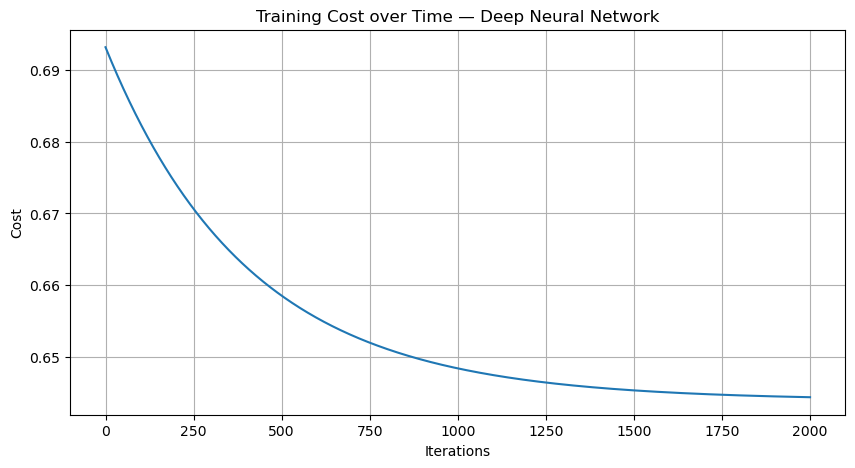

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations')
plt.title('Training Cost over Time — Deep Neural Network')
plt.grid(True)
plt.show()

## Observations

- The network is generalized to L layers using for loops — same equations, any depth
- Each hidden layer learns increasingly abstract representations of the input
- Small dataset (209 examples) limits how well deeper networks can generalize
- Fully connected architecture still cannot capture spatial structure of images

→ The next step is Convolutional Neural Networks, which preserve spatial structure through learned filters.